# Final Exam BUS 458 — Loan Data Analysis
## Name: Sophia Amsden 
## Unity ID: 200457301
**Objective:** Your objective is to identify the key drivers of loan approval and recommend which lender should be prioritized for each customer to maximize total payout

### **Instructions**
- Follow the prompts in each section of this notebook.
- **Where you see a “Question,” answer it directly below in a Markdown (text) cell — not as a code comment.**
- Your **reasoning, interpretations, and insights** should be written in text cells, clearly separated from code.
- You are encouraged to add extra **code cells**, **visualizations**, or **short explanations** if they strengthen your analysis or help you justify decisions.
- Make sure your notebook runs cleanly from start to finish without errors.


In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Load Data (via Google Drive or direct upload)

In [121]:
df = pd.read_csv(r"C:\Users\Lenovo\Downloads\loan_data_analysis_final.csv")

In [123]:
# Check first 5 rows of dataframe
df.head()

,User ID,applications,Reason,Granted_Loan_Amount,Requested_Loan_Amount,FICO_score,Fico_Score_group,Employment_Status,Employment_Sector,Monthly_Gross_Income,Monthly_Housing_Payment,Ever_Bankrupt_or_Foreclose,Lender,Approved,bounty
0,00007820-89cb-4c1d-9940-eb270d605a35,1,cover_an_unexpected_cost,100000,123000.0,669.0,fair,full_time,consumer_discretionary,5024.0,927,0,B,0,0
1,00012b55-514c-421e-9c76-3300abbc1134,1,credit_card_refinancing,70000,79000.0,594.0,fair,full_time,information_technology,5764.0,1177,0,B,0,0
2,000157c1-b6a3-4c86-82c7-9ec1bda3799a,1,home_improvement,10000,11000.0,596.0,fair,full_time,information_technology,4017.0,1487,0,A,0,0
3,00020400-efab-4b10-8812-2a0aaf774841,1,home_improvement,100000,120000.0,642.0,fair,part_time,energy,3129.0,904,0,A,0,0
4,0002f737-0cda-48fb-91ed-533f3d0eab05,1,major_purchase,30000,34000.0,NaN,fair,full_time,energy,NaN,1620,0,A,0,0


In [125]:
# Drop columns that have no variation or are unique
df = df.loc[:, df.nunique() > 1]          
df = df.loc[:, df.nunique() < len(df)]    

Understand the Data: Get a quick overview of the dataset structure and variable meanings before preprocessing.

In [128]:
# Shape (rows, columns)
print( df.shape)

# Column types & non-null counts
df.info()

# Identify numeric and categorical columns
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object','category']).columns.tolist()

(100000, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Reason                      100000 non-null  object 
 1   Granted_Loan_Amount         100000 non-null  int64  
 2   Requested_Loan_Amount       100000 non-null  float64
 3   FICO_score                  85000 non-null   float64
 4   Fico_Score_group            100000 non-null  object 
 5   Employment_Status           100000 non-null  object 
 6   Employment_Sector           93593 non-null   object 
 7   Monthly_Gross_Income        85000 non-null   float64
 8   Monthly_Housing_Payment     100000 non-null  int64  
 9   Ever_Bankrupt_or_Foreclose  100000 non-null  int64  
 10  Lender                      100000 non-null  object 
 11  Approved                    100000 non-null  int64  
 12  bounty                      100000 non-null  int64  
dtypes:

## 1. Preprocessing


### 1.1 Handling Missing Values

**Question:** Why is median imputation often preferable to mean imputation for income and FICO?


**Answer:** Mean is more sensitive to outliers and income and FICO scores tend to be skewed, so it is preferred to use median so that the center is more accurate and the outliers don't pull the center up or down. 




In [132]:
# Inspect missing values
print("Missing values per column:")
print(df.isna().sum())

Missing values per column:
Reason                            0
Granted_Loan_Amount               0
Requested_Loan_Amount             0
FICO_score                    15000
Fico_Score_group                  0
Employment_Status                 0
Employment_Sector              6407
Monthly_Gross_Income          15000
Monthly_Housing_Payment           0
Ever_Bankrupt_or_Foreclose        0
Lender                            0
Approved                          0
bounty                            0
dtype: int64


Summary Statistics (Numeric Columns):


,Granted_Loan_Amount,Requested_Loan_Amount,FICO_score,Monthly_Gross_Income,Monthly_Housing_Payment,Ever_Bankrupt_or_Foreclose,Approved,bounty
count,1.000000e+05,1.000000e+05,85000.000000,85000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,6.478465e+04,7.450309e+04,629.338153,5808.783776,1888.900720,0.022460,0.109760,26.415000
std,1.965837e+05,2.264856e+05,88.684201,2988.185274,3431.924282,0.148175,0.312592,78.385644
min,5.000000e+03,5.000000e+03,300.000000,-17702.000000,300.000000,0.000000,0.000000,0.000000
25%,2.000000e+04,2.400000e+04,572.000000,3659.000000,1231.000000,0.000000,0.000000,0.000000
50%,4.000000e+04,4.400000e+04,634.000000,5153.500000,1669.000000,0.000000,0.000000,0.000000
75%,7.000000e+04,8.400000e+04,693.000000,7612.000000,2051.000000,0.000000,0.000000,0.000000
max,2.000000e+06,2.500000e+06,850.000000,19997.000000,49500.000000,1.000000,1.000000,350.000000


Summary Statistics (Categorical Columns):


,Reason,Fico_Score_group,Employment_Status,Employment_Sector,Lender
count,100000,100000,100000,93593,100000
unique,6,5,3,11,3
top,debt_conslidation,fair,full_time,information_technology,A
freq,27622,36475,76530,19748,55000


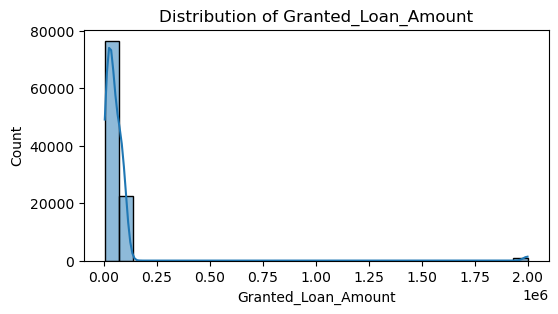

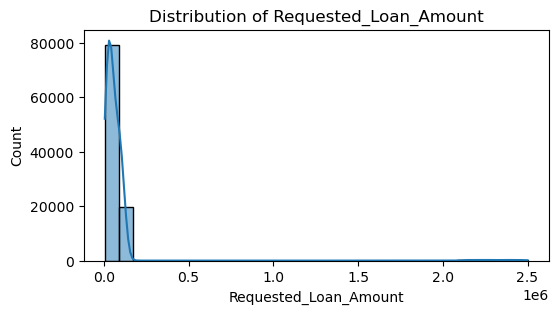

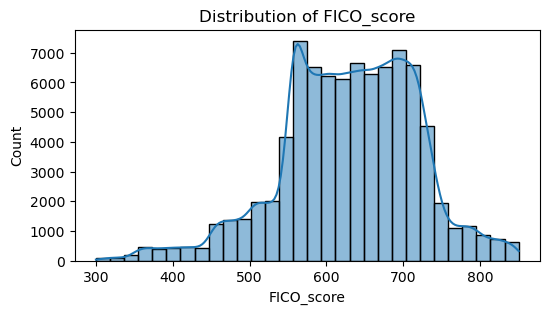

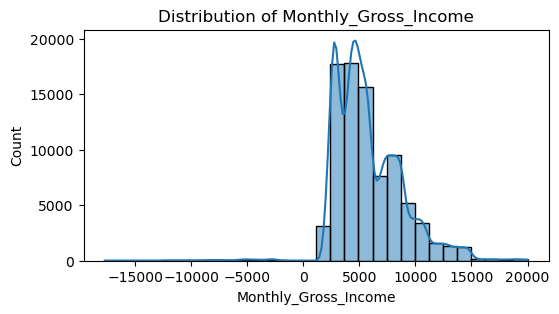

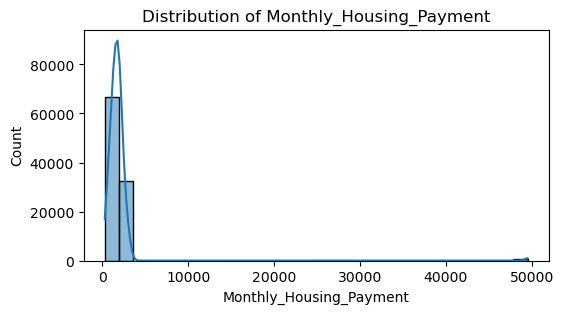

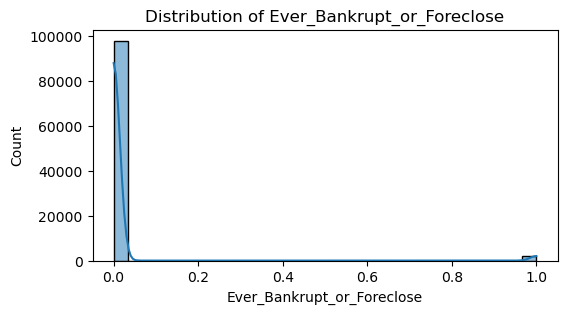

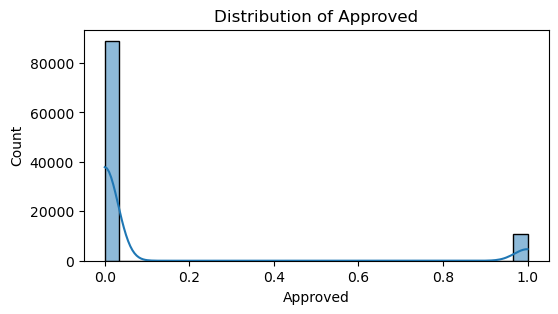

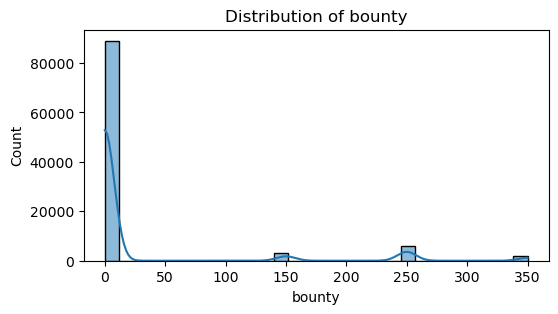

In [134]:
# Exploratory analysis

# Numeric summary statistics
print("Summary Statistics (Numeric Columns):")
display(df[numeric_cols].describe())
# Interpretation: 
# Most loans and incomes are right-skewed with some extreme outliers, so the mean is higher than the median. 
# FICO_score and Monthly_Gross_Income have missing values that need imputation. 
# Binary columns like Approved and Ever_Bankrupt_or_Foreclose are highly imbalanced. 
# Some data errors exist (e.g., negative incomes) and will need cleaning before analysis.

# Categorical summary statistics
print("Summary Statistics (Categorical Columns):")
display(df[categorical_cols].describe())
# Interpretation:
# Most applicants applied for loans for debt consolidation. Fico_Score_group is dominated by the fair category. 
# Most borrowers are full-time employed, with the largest employment sector being information_technology. 
# Lender A is the most common, and Employment_Sector has some missing values.

# Distribution plots for numeric columns
for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()
# Interpretation:
# There are some extreme outliers in most columns. There is a right-skew of monthly gross income.


In [135]:
# Apply imputation as instructed in the instructions pdf (create copies so original rows can be restored if needed)

# Impute
# Create a copy
df_imputed = df.copy()

# Impute numeric columns with median
df_imputed['FICO_score'] = df_imputed['FICO_score'].fillna(df_imputed['FICO_score'].median())
df_imputed['Monthly_Gross_Income'] = df_imputed['Monthly_Gross_Income'].fillna(df_imputed['Monthly_Gross_Income'].median())

# Impute categorical column with 'Unknown'
df_imputed['Employment_Sector'] = df_imputed['Employment_Sector'].fillna('Unknown')

# Quick check to confirm missing values handled
print("Missing values after imputation:")
print(df_imputed[['FICO_score','Monthly_Gross_Income','Employment_Sector']].isna().sum())


Missing values after imputation:
FICO_score              0
Monthly_Gross_Income    0
Employment_Sector       0
dtype: int64


### 1.2 Outliers Detection and Removal

**Question:**
Which features had the most outliers, and what impact could they have on the model?

**Answer** : Most outliers occur in Monthly Gross Income and FICO score, with moderate outliers in loan amounts. Outliers can strongly skew Logistic Regression coefficients and predictions, but they have little effect on Decision Trees because splits are based on thresholds rather than averages.

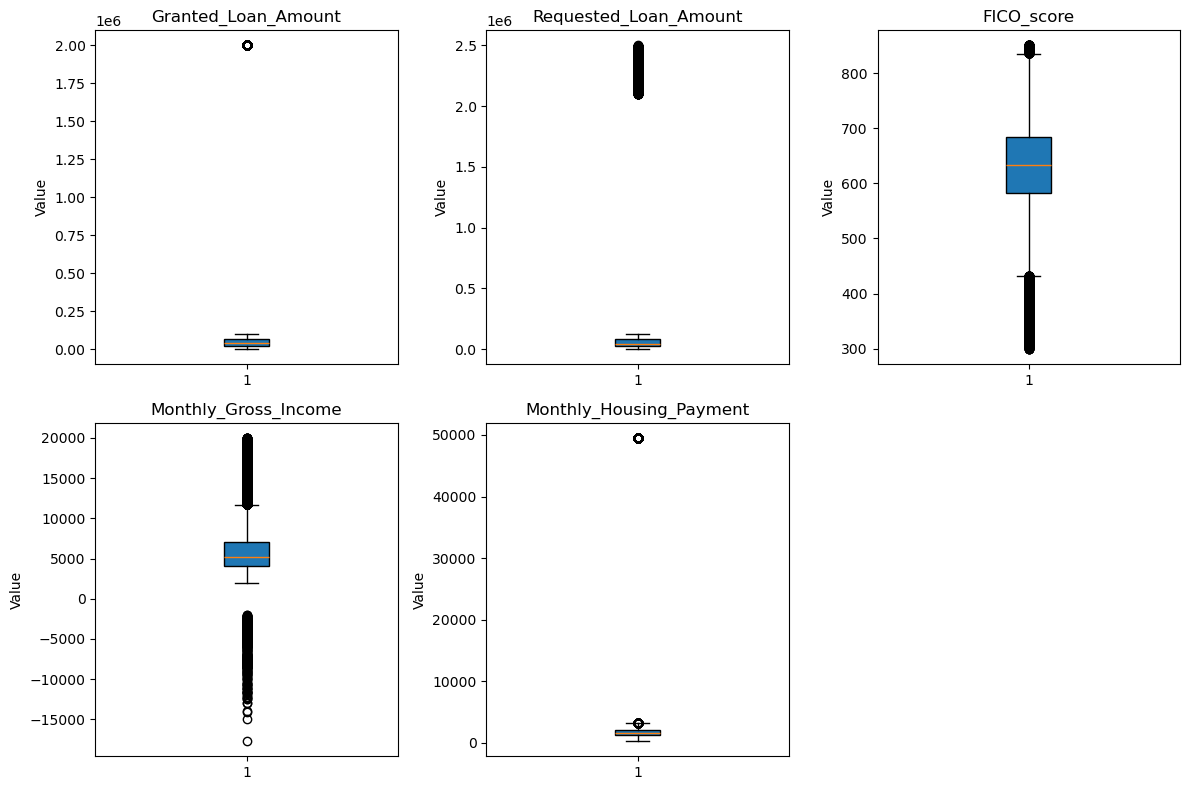

Granted_Loan_Amount: 1000 outliers (1.00%)
Requested_Loan_Amount: 1000 outliers (1.00%)
FICO_score: 1205 outliers (1.21%)
Monthly_Gross_Income: 2258 outliers (2.26%)
Monthly_Housing_Payment: 613 outliers (0.61%)


In [139]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

numeric_cols = ['Granted_Loan_Amount', 'Requested_Loan_Amount', 'FICO_score', 'Monthly_Gross_Income', 'Monthly_Housing_Payment']

# Boxplots to highlight outliers for numerical columns
plt.figure(figsize=(12, 8))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)  # 2 rows, 3 columns
    plt.boxplot(df_imputed[col], vert=True, patch_artist=True)
    plt.title(col)
    plt.ylabel('Value')

plt.tight_layout()
plt.show()

# Optionally, count the number of outliers using IQR method
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f'{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)')

In [141]:
# Remove Outliers using Z-score

from scipy import stats
import numpy as np

# Compute Z-scores for only numeric columns
z_scores = np.abs(stats.zscore(df[numeric_cols], nan_policy='omit'))

# Choose threshold
threshold = 3  # common choice: 3 standard deviations

# Identify rows to keep (all Z-scores <= threshold)
rows_to_keep = (z_scores < threshold).all(axis=1)

# Track counts before/after
before_count = df.shape[0]
df_clean = df[rows_to_keep].copy()
after_count = df_clean.shape[0]

print(f"Outlier removal complete:")
print(f"Rows before: {before_count}")
print(f"Rows after:  {after_count}")
print(f"Rows removed: {before_count - after_count}")



Outlier removal complete:
Rows before: 100000
Rows after:  69831
Rows removed: 30169


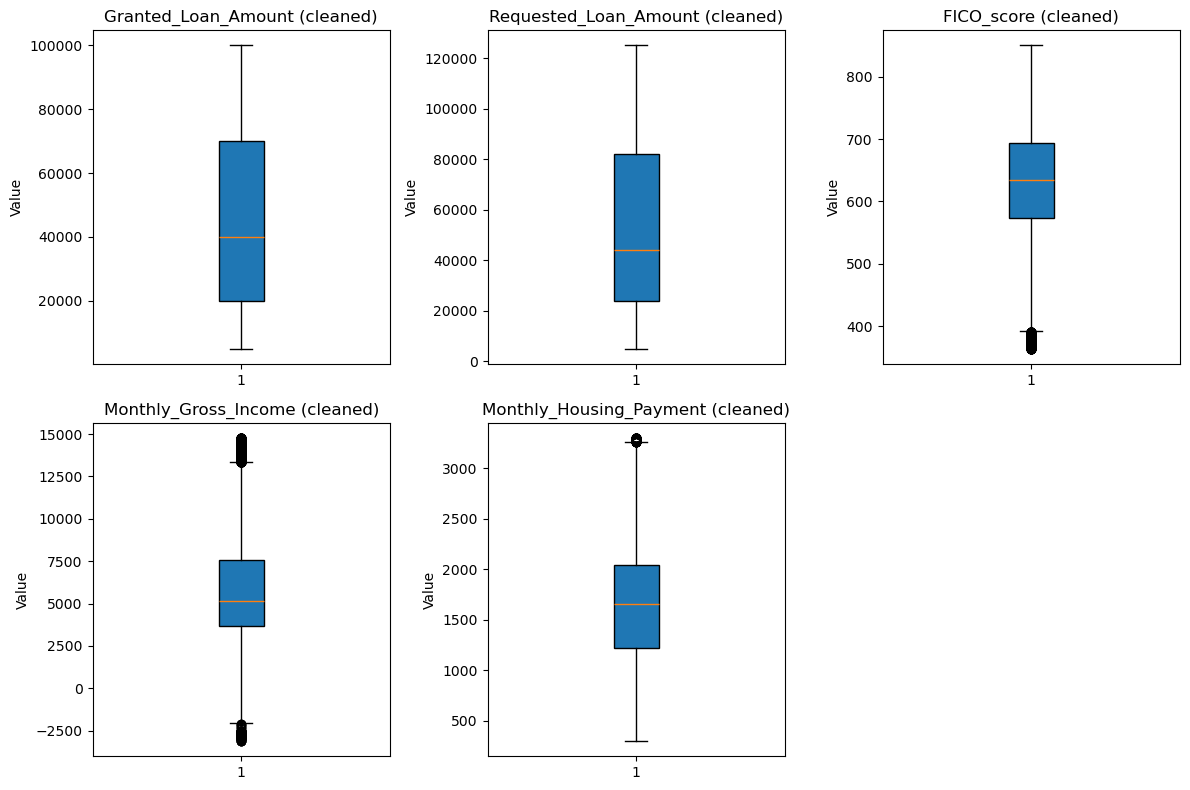

Granted_Loan_Amount: 0 outliers (0.00%)
Requested_Loan_Amount: 0 outliers (0.00%)
FICO_score: 534 outliers (0.76%)
Monthly_Gross_Income: 1211 outliers (1.73%)
Monthly_Housing_Payment: 151 outliers (0.22%)


In [143]:
# BoxPlots after outlier removal
plt.figure(figsize=(12, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    plt.boxplot(df_clean[col], vert=True, patch_artist=True)
    plt.title(f'{col} (cleaned)')
    plt.ylabel('Value')
plt.tight_layout()
plt.show()

# Count outliers using IQR method
for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]
    print(f'{col}: {len(outliers)} outliers ({len(outliers)/len(df_clean)*100:.2f}%)')


**Question:**
Why do we need to remove or treat outliers? Provide reasoning based on model performance or data integrity.

**Answer** : Outliers can distort statistical summaries and bias model predictions. Removing or treating them improves model accuracy, stability, and ensures the data reflects real patterns.


**Question:**
Is there a difference between boxplots before and after outlier removal?

**Answer** : Yes. Before outlier removal, the boxplots were compressed due to extreme values. After removing outliers, the plots are more spread out, making the distributions clearer and easier to interpret.

### 1.3 Redundancy & Correlation Check (5 Marks)

Detect duplicate data and multicollinearity.

**Question:**
Which numerical variables appear most strongly correlated with each other?

**Answer:** Granted Loan Amount and Requested Loan Amount are perfectly correlated (1.00), meaning they carry nearly identical information. There is also a moderate correlation between FICO Score and Monthly Gross Income (0.29), and FICO Score and Approved (0.27).



**Question:**
Which numerical and categorical are strongly corelated to each other?

**Answer:** The strongest relationships are FICO Score and FICO Score Group (0.92), since one is derived from the other, Monthly Gross Income and Employment Status (0.53), and Monthly Gross Income and FICO Score Group (0.31). 


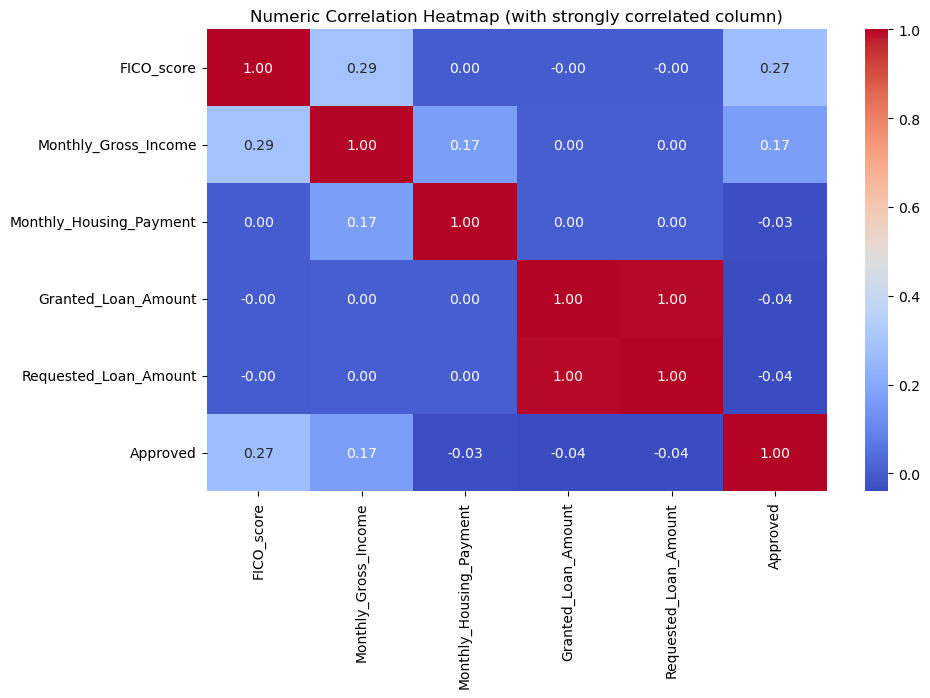

In [147]:
# Correlation between numerical features
numeric_cols = ['FICO_score', 'Monthly_Gross_Income', 'Monthly_Housing_Payment', 'Granted_Loan_Amount','Requested_Loan_Amount', 'Approved']

# Plot correlation matrix, identify highly correlated pairs automatically (|corr|>0.95, excluding self-correlation)
corr = df_clean[numeric_cols].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Numeric Correlation Heatmap (with strongly correlated column)")
plt.show()


Top 10 Numeric-Categorical Correlation Ratios (η²):
FICO_score - Fico_Score_group: η² = 0.850 (η = 0.922)
Monthly_Gross_Income - Employment_Status: η² = 0.282 (η = 0.531)
Monthly_Gross_Income - Fico_Score_group: η² = 0.095 (η = 0.308)
Monthly_Gross_Income - Employment_Sector: η² = 0.081 (η = 0.285)
Monthly_Housing_Payment - Employment_Status: η² = 0.040 (η = 0.199)
Ever_Bankrupt_or_Foreclose - Employment_Status: η² = 0.030 (η = 0.174)
Monthly_Housing_Payment - Lender: η² = 0.028 (η = 0.167)
Ever_Bankrupt_or_Foreclose - Employment_Sector: η² = 0.026 (η = 0.163)
Monthly_Gross_Income - Lender: η² = 0.009 (η = 0.096)
Monthly_Housing_Payment - Employment_Sector: η² = 0.005 (η = 0.071)


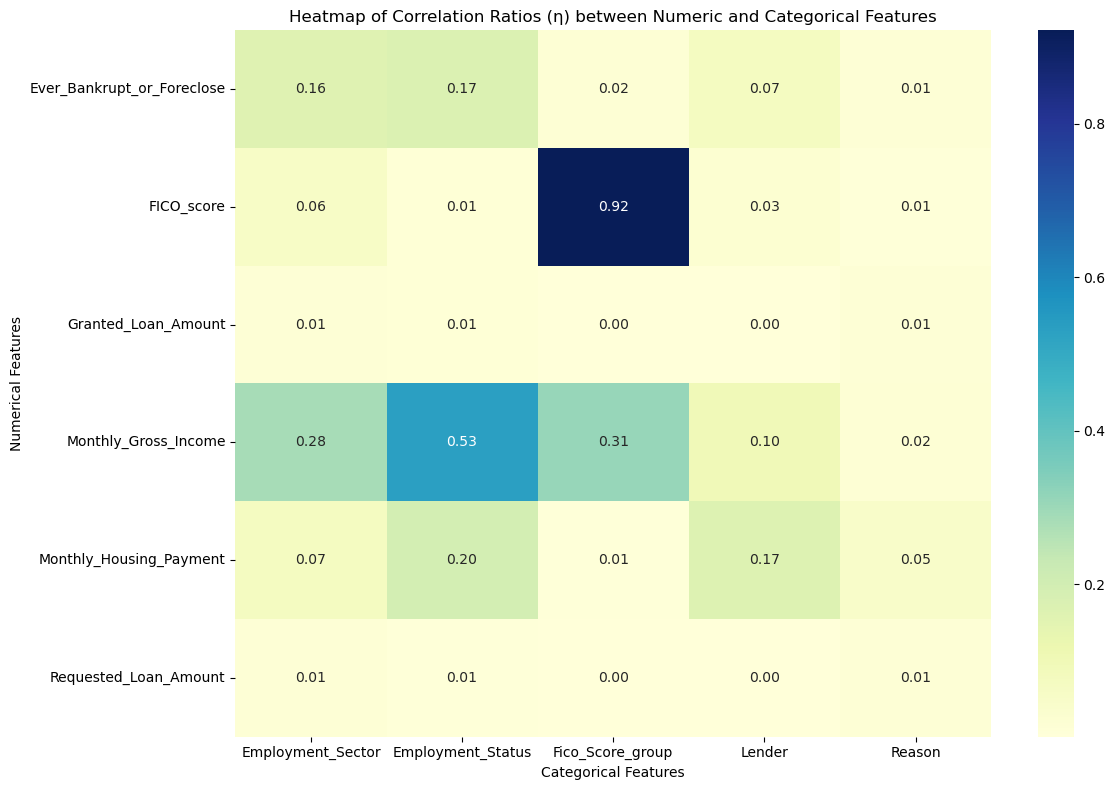

In [149]:
# Correlation between Numeric and Categorical Variables (Correlation Ratio / η²)
from scipy import stats

def correlation_ratio(categories, values):
    categories = np.array(categories.fillna('Missing').astype(str))
    values = np.array(values)
    cat_levels = np.unique(categories)
    overall_mean = np.mean(values)
    numerator = sum(len(values[categories == cat]) *
                    (np.mean(values[categories == cat]) - overall_mean) ** 2
                    for cat in cat_levels)
    denominator = sum((values - overall_mean) ** 2)
    return np.sqrt(numerator / denominator) if denominator != 0 else 0

# test all numeric–categorical pairs
num_cat_results = []


# Identify categorical and numerical columns
categorical_cols_clean = df_clean.select_dtypes(include='object').columns.tolist()
numeric_cols_clean = df_clean.select_dtypes(include=np.number).columns.tolist()


numeric_cols_for_eta = [col for col in numeric_cols_clean if col not in ['bounty', 'Approved', ]]
categorical_cols_for_eta = [col for col in categorical_cols_clean]


for num_col in numeric_cols_for_eta:
    for cat_col in categorical_cols_for_eta:
        eta = correlation_ratio(df_clean[cat_col], df_clean[num_col])
        num_cat_results.append((num_col, cat_col, eta))

num_cat_results = sorted(num_cat_results, key=lambda x: x[2], reverse=True)
print("Top 10 Numeric-Categorical Correlation Ratios (η²):")
for num_col, cat_col, eta in num_cat_results[:10]:
    print(f"{num_col} - {cat_col}: η² = {eta**2:.3f} (η = {eta:.3f})")


# Reorganize the correlation ratio results into a pivot table/matrix for heatmap
eta_matrix = pd.DataFrame(num_cat_results, columns=['Numerical_Feature', 'Categorical_Feature', 'Eta'])
eta_pivot = eta_matrix.pivot(index='Numerical_Feature', columns='Categorical_Feature', values='Eta')

# Plot the heatmap of correlation ratios (Eta)
plt.figure(figsize=(12, 8))
sns.heatmap(eta_pivot, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Heatmap of Correlation Ratios (η) between Numeric and Categorical Features")
plt.xlabel("Categorical Features")
plt.ylabel("Numerical Features")
plt.tight_layout()
plt.show()



**Questions:** What features will you consider dropping after analyzing the graphs above?

**Answer** : I would consider dropping Requested Loan Amount or Granted Loan Amount since they are perfectly correlated, so one can be removed for models sensitive to multicollinearity (Logistic Regression). FICO Score Group can be removed if FICO Score is kept, since it's a binned version of the same data and doesn't add new information.



> *Note: For Decision Tree models, you do not need to remove or adjust for collinearity. The algorithm can naturally handle correlated features through its splitting mechanism. However, for Logistic Regression, multicollinearity can distort coefficient estimates and make interpretations unreliable. In that case, you may consider removing one variable from highly correlated pairs.


## 2. Exploratory Data Analysis

### 2.1 Target Variable Distribution

Analyze the distribution of the target variable (Approved) to understand class balance in loan approval outcomes.


**Question:**
Is the dataset balanced or imbalanced? Briefly explain the implication for modeling.


**Answer:**
The data is imbalanced. There are way more not approved loans (about 60k) compared to approved ones (around 10k). This means a model could look like it’s performing well just by predicting “not approved” most of the time, even though it wouldn’t actually do a good job identifying the approvals we care about. We may need to use techniques like resampling or class weights to address this.

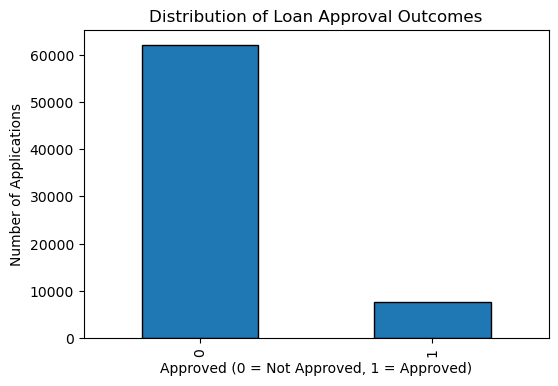

In [154]:
# Plot 'Approved' to visualise the count and balance
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df_clean['Approved'].value_counts().plot(kind='bar', edgecolor='black')

plt.title("Distribution of Loan Approval Outcomes")
plt.xlabel("Approved (0 = Not Approved, 1 = Approved)")
plt.ylabel("Number of Applications")
plt.show()


### 2.2 Distribution of Numerical Variables by Approval

Explore how key numerical variables differ between approved and rejected loan applications.


**Question:**
Which numerical variable is the most helpful variable ( most crucial predictor) ?

**Answer:**
Based on the plots, FICO_score is the most crucial numerical predictor because its distributions for approved vs. denied loans overlap the least, and the medians are farthest apart, making it the strongest discriminator


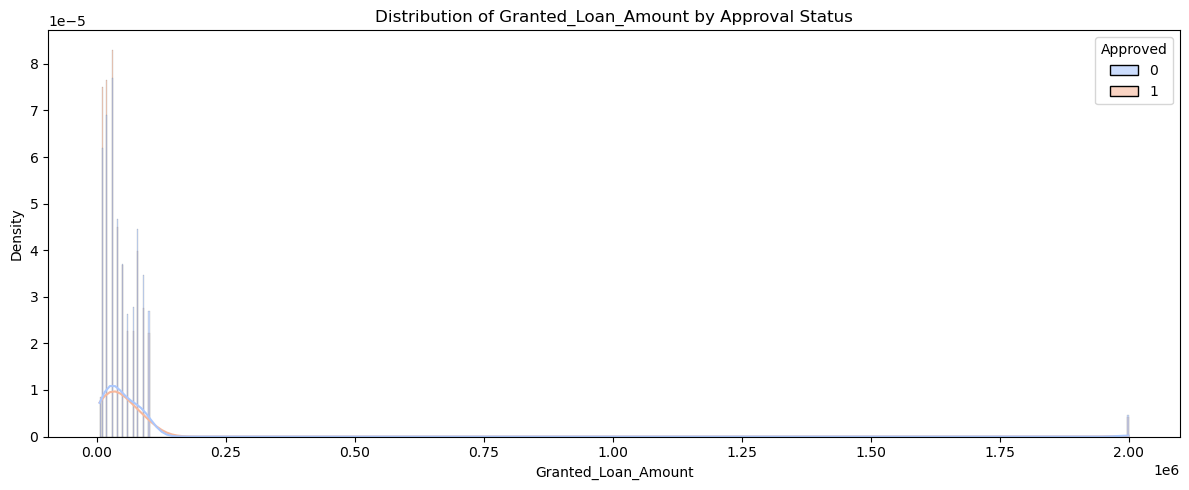

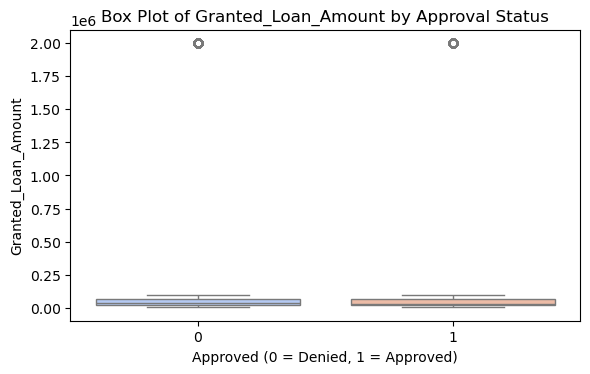

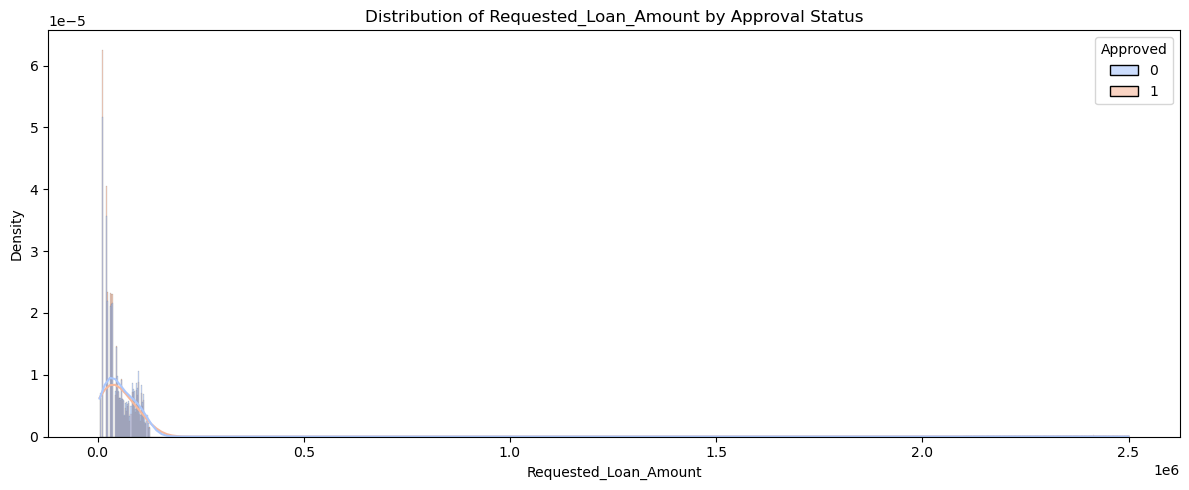

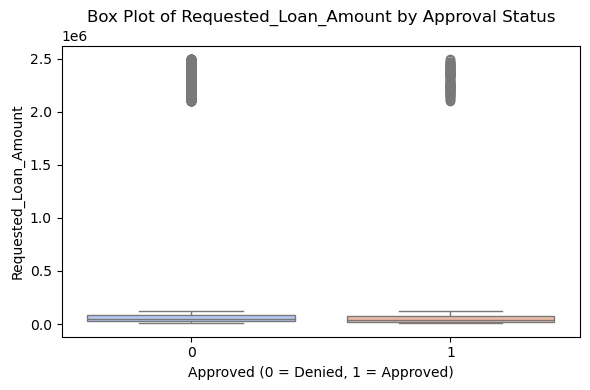

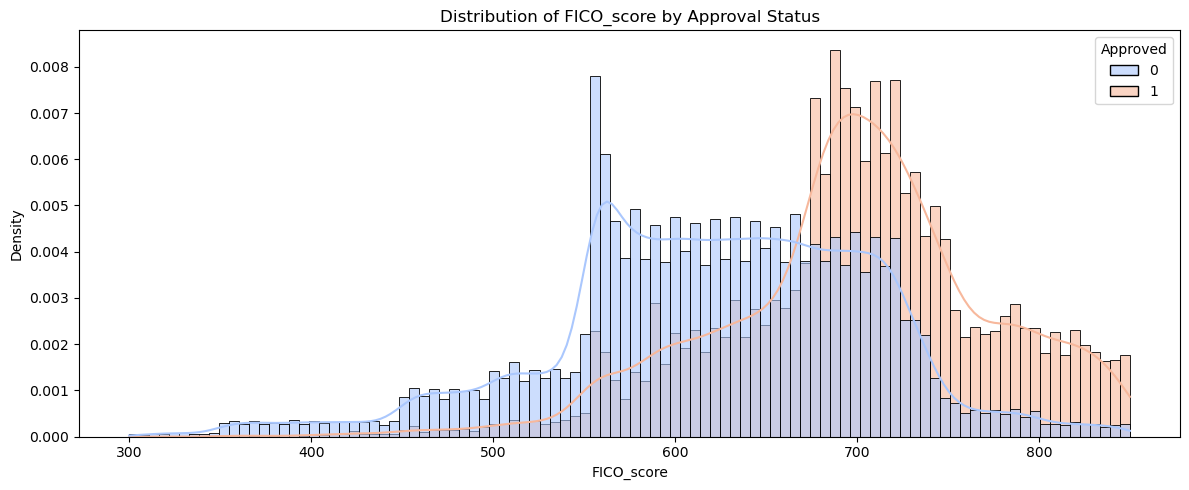

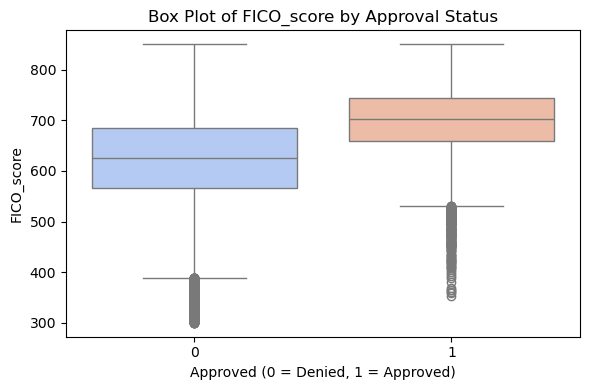

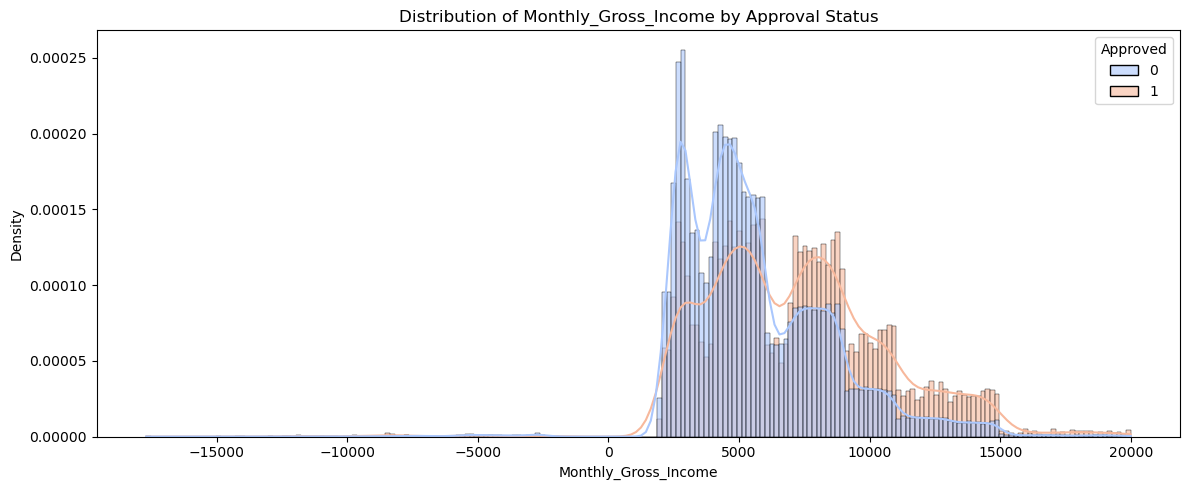

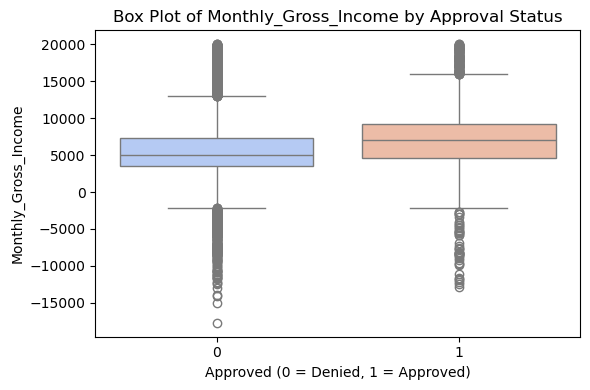

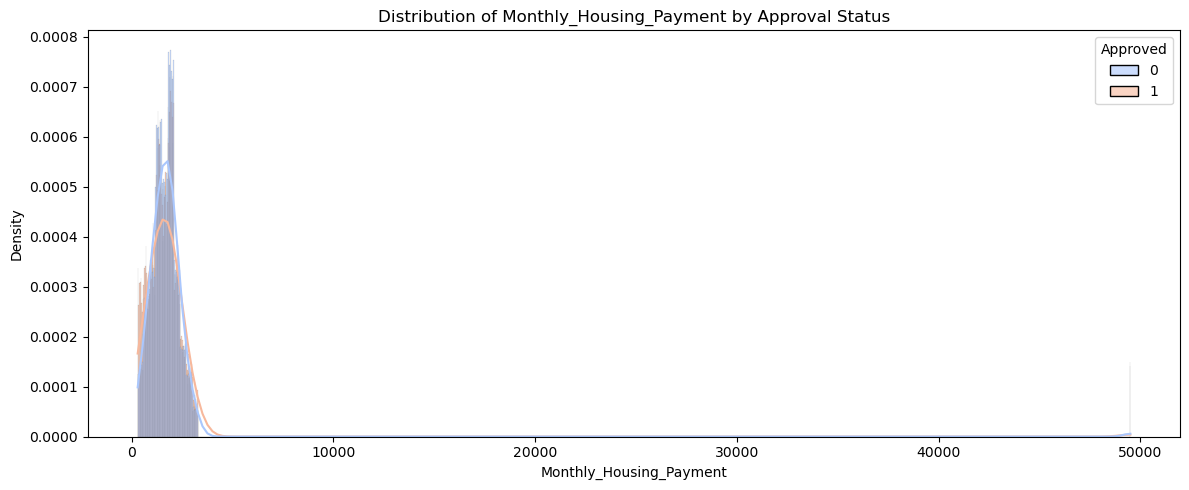

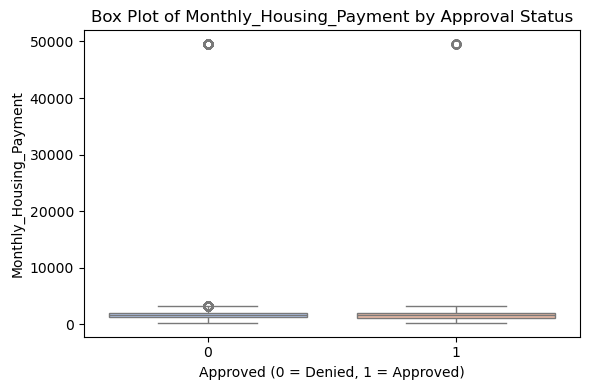

In [157]:
# Visualise numerical variables against target variable

numerical_cols = ['Granted_Loan_Amount', 'Requested_Loan_Amount','FICO_score', 'Monthly_Gross_Income', 'Monthly_Housing_Payment']

for col in numerical_cols:
    plt.figure(figsize=(12,5))
    sns.histplot(
        data=df,
        x=col,
        hue='Approved',
        kde=True,
        stat='density',
        common_norm=False,
        palette='coolwarm',
        alpha=0.6
    )
    plt.title(f'Distribution of {col} by Approval Status')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,4))
    sns.boxplot(
        data=df,
        x='Approved',
        y=col,
        hue='Approved',
        palette='coolwarm',
        legend=False
    )
    plt.title(f'Box Plot of {col} by Approval Status')
    plt.xlabel('Approved (0 = Denied, 1 = Approved)')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


### 2.3 Categorical Variables and Approval

Analyze how categorical variables (such as Employment_Sector, Loan_Purpose, or Residence_Type) relate to the loan approval outcome.


**Question:**
Which categorical variable appears to have the strongest relationship with loan approval, and how can you tell?

**Answer:**
It looks like FICO score group has the strongest relationship with loan approval because approval rates vary drastically across FICO score groups.


**Question:**
Are there any categories (e.g., Reason, Employment_Status) that appear to have minimal predictive value? Justify your answer with approval rate differences.

**Answer:**
Reason appears to have minimal predictive value because approval rate looks about the same across every reason.

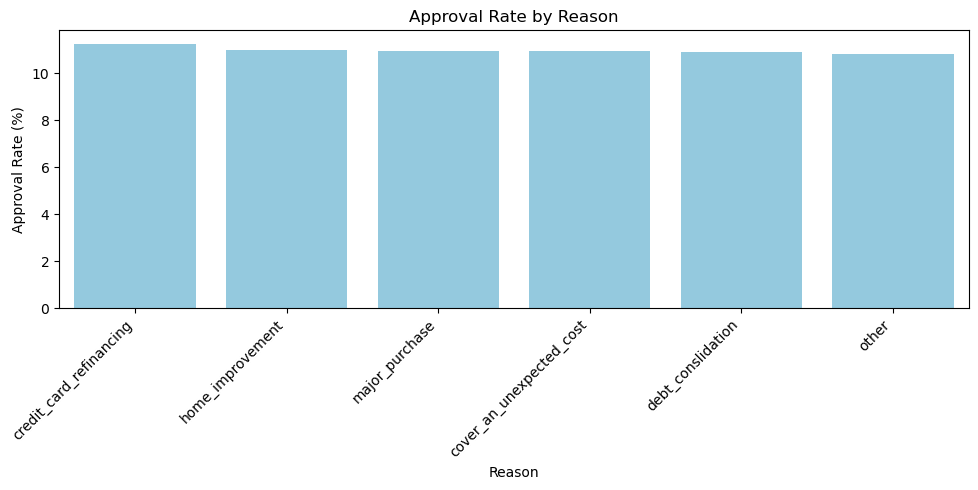


Approval Rate by Reason:
Reason
credit_card_refinancing     11.27
home_improvement            10.98
major_purchase              10.95
cover_an_unexpected_cost    10.93
debt_conslidation           10.89
other                       10.81
Name: Approved, dtype: float64


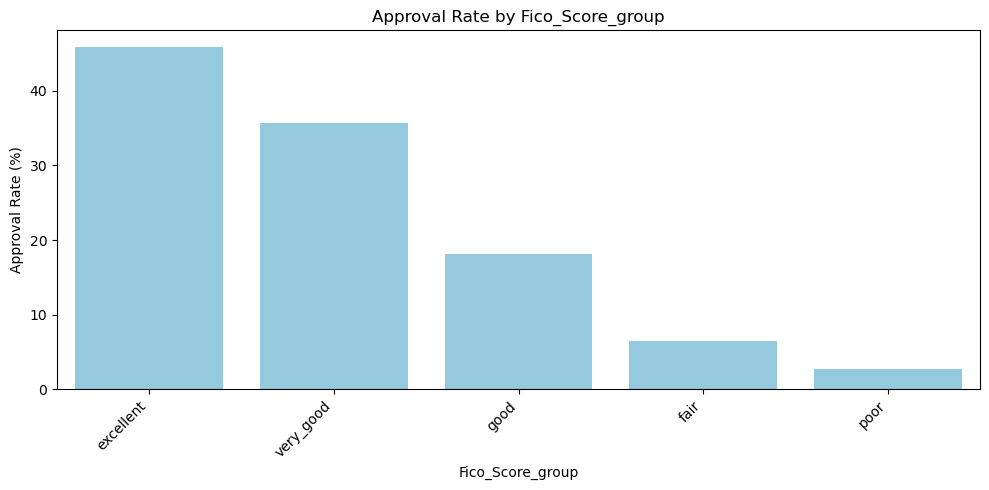


Approval Rate by Fico_Score_group:
Fico_Score_group
excellent    45.80
very_good    35.65
good         18.06
fair          6.44
poor          2.78
Name: Approved, dtype: float64


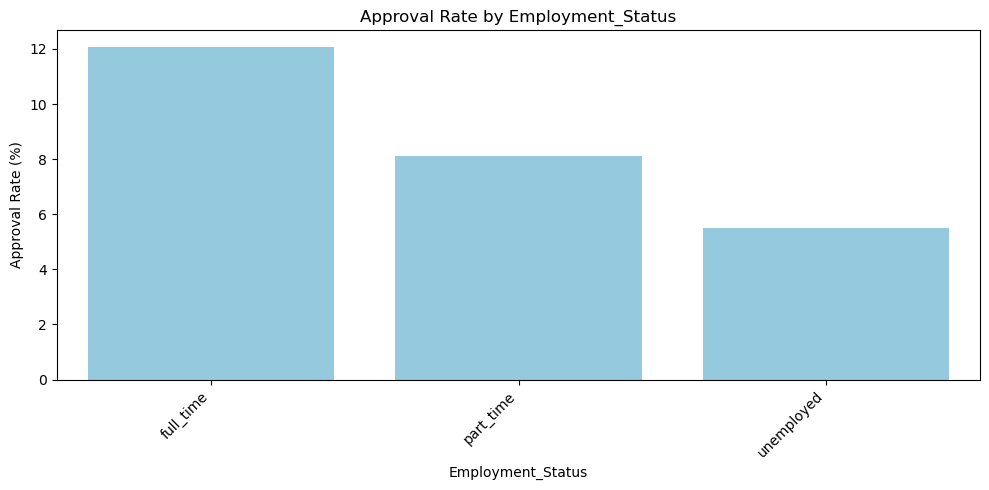


Approval Rate by Employment_Status:
Employment_Status
full_time     12.07
part_time      8.12
unemployed     5.49
Name: Approved, dtype: float64


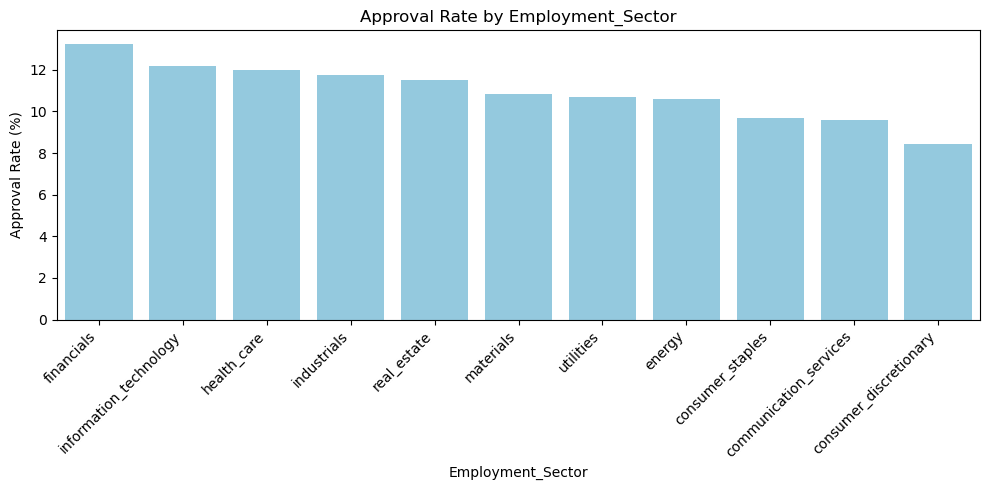


Approval Rate by Employment_Sector:
Employment_Sector
financials                13.24
information_technology    12.20
health_care               11.97
industrials               11.75
real_estate               11.50
materials                 10.83
utilities                 10.71
energy                    10.60
consumer_staples           9.68
communication_services     9.57
consumer_discretionary     8.42
Name: Approved, dtype: float64


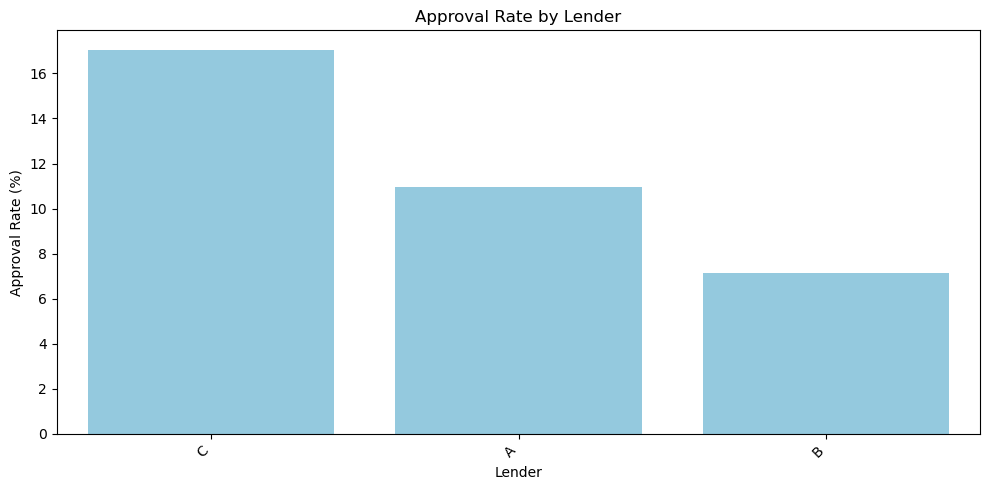


Approval Rate by Lender:
Lender
C    17.06
A    10.97
B     7.13
Name: Approved, dtype: float64


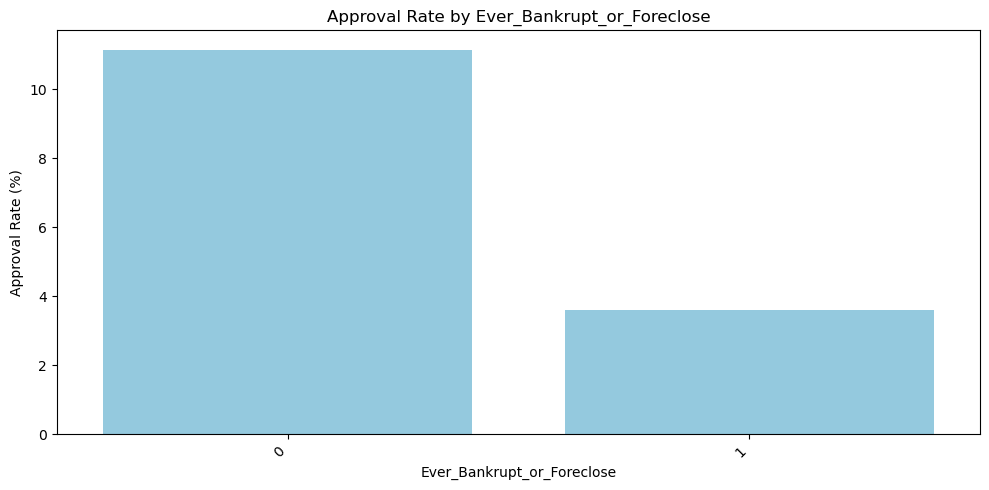


Approval Rate by Ever_Bankrupt_or_Foreclose:
Ever_Bankrupt_or_Foreclose
0    11.15
1     3.61
Name: Approved, dtype: float64


In [160]:
# Visualise categorical variables against target variable

categorical_cols = [
    'Reason', 'Fico_Score_group', 'Employment_Status',
    'Employment_Sector', 'Lender', 'Ever_Bankrupt_or_Foreclose'
]

for col in categorical_cols:
    approval_rates = df.groupby(col)['Approved'].mean().sort_values(ascending=False) * 100

    plt.figure(figsize=(10,5))
    sns.barplot(x=approval_rates.index, y=approval_rates.values, color='skyblue')
    plt.title(f'Approval Rate by {col}')
    plt.xlabel(col)
    plt.ylabel('Approval Rate (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print(f"\nApproval Rate by {col}:\n{approval_rates.round(2)}")


### Cross Feature plots for multi-dimensional analysis.

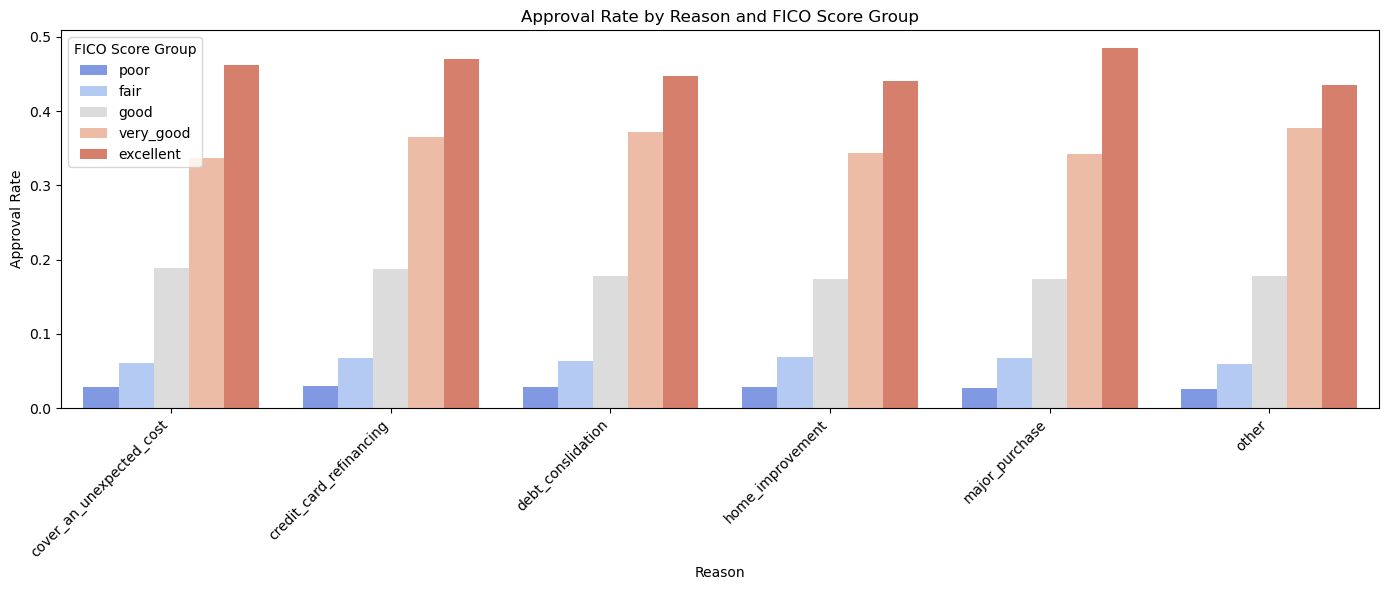

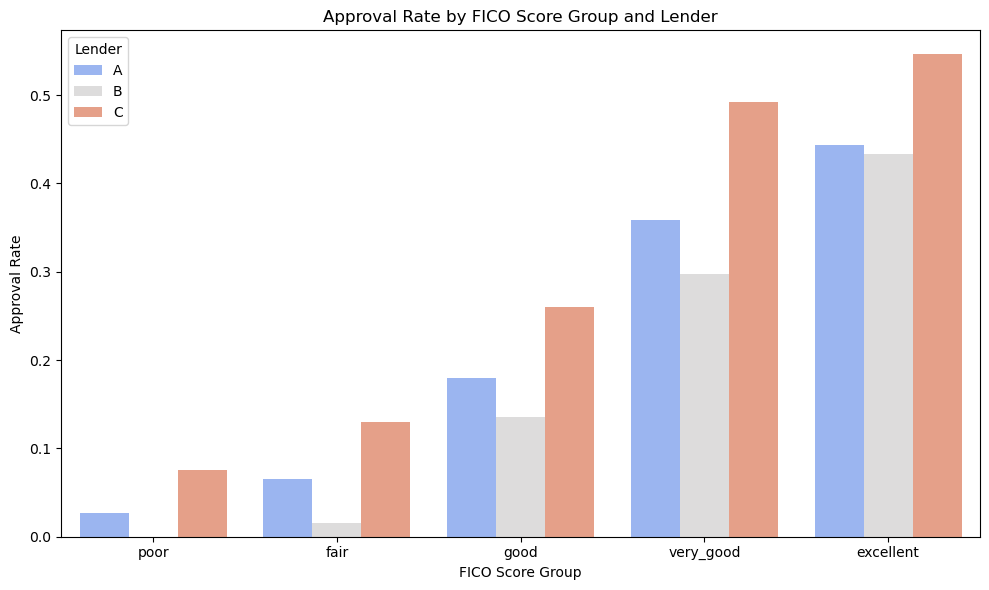

Approval Rate by FICO Score Group and Lender:
Lender                A      B      C
Fico_Score_group                     
excellent         44.37  43.33  54.62
fair               6.57   1.54  13.02
good              17.97  13.59  26.01
poor               2.63   0.00   7.55
very_good         35.85  29.78  49.18


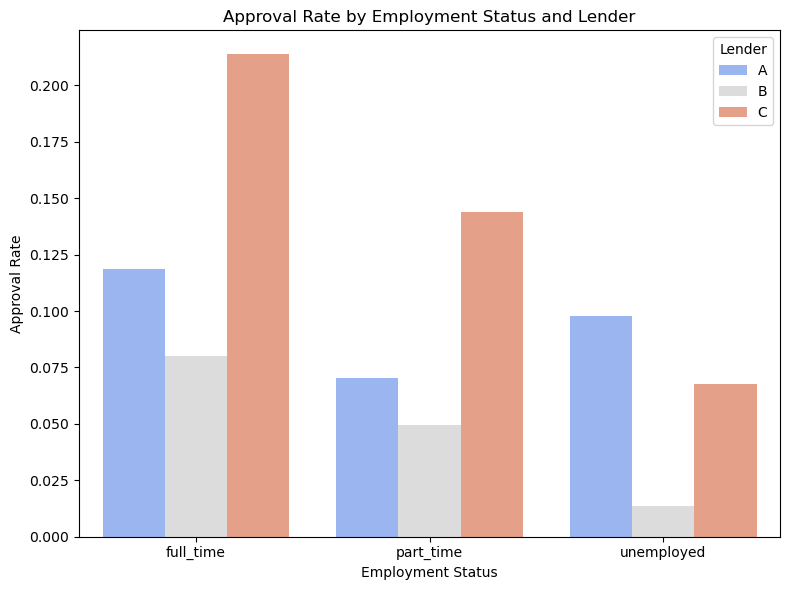

Approval Rate by Employment Status and Lender:
Lender                 A     B      C
Employment_Status                    
full_time          11.88  8.01  21.38
part_time           7.04  4.95  14.41
unemployed          9.78  1.35   6.75


In [163]:
# Approval rate by Reason and FICO Score Group (grouped bar plot)
fico_order = ['poor', 'fair', 'good', 'very_good', 'excellent']

approval_by_reason_fico = (
    df.groupby(['Reason', 'Fico_Score_group'])['Approved']
      .mean()
      .reset_index()
)

plt.figure(figsize=(14,6))
sns.barplot(
    data=approval_by_reason_fico,
    x='Reason',
    y='Approved',
    hue='Fico_Score_group',
    hue_order=fico_order,  # specify correct order
    palette='coolwarm'
)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Approval Rate")
plt.title("Approval Rate by Reason and FICO Score Group")
plt.legend(title='FICO Score Group')
plt.tight_layout()
plt.show()

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure FICO categories are in logical order
fico_order = ['poor', 'fair', 'good', 'very_good', 'excellent']

# Approval Rate by FICO Score Group and Lender (Grouped Bar Plot)
approval_fico_lender = df.groupby(['Fico_Score_group', 'Lender'])['Approved'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(
    data=approval_fico_lender,
    x='Fico_Score_group',
    y='Approved',
    hue='Lender',
    hue_order=sorted(df['Lender'].unique()),  # ensure consistent order
    order=fico_order,
    palette='coolwarm'
)
plt.title("Approval Rate by FICO Score Group and Lender")
plt.ylabel("Approval Rate")
plt.xlabel("FICO Score Group")
plt.legend(title="Lender")
plt.tight_layout()
plt.show()
print("Approval Rate by FICO Score Group and Lender:")
print(approval_fico_lender.pivot(index='Fico_Score_group', columns='Lender', values='Approved').round(4) * 100)

# Approval Rate by Employment Status and Lender (Grouped Bar Plot)
approval_emp_lender = df.groupby(['Employment_Status', 'Lender'])['Approved'].mean().reset_index()

plt.figure(figsize=(8,6))
sns.barplot(
    data=approval_emp_lender,
    x='Employment_Status',
    y='Approved',
    hue='Lender',
    hue_order=sorted(df['Lender'].unique()),  # consistent order
    palette='coolwarm'
)
plt.title("Approval Rate by Employment Status and Lender")
plt.ylabel("Approval Rate")
plt.xlabel("Employment Status")
plt.legend(title="Lender")
plt.tight_layout()
plt.show()
print("Approval Rate by Employment Status and Lender:")
print(approval_emp_lender.pivot(index='Employment_Status', columns='Lender', values='Approved').round(4) * 100)

## 3.5 Business Insights from EDA

After completing your visualizations and cross-feature analyses, summarize your findings in the context of loan approval and lender matching.  
Use this section to connect data patterns to real-world meaning before building predictive models.


**Question:** Which variables are the most helpful in understanding if a customer is going to be approved or denied for a loan?  

**Answer**: The variables that seem to matter most for predicting whether someone gets approved are FICO_score / FICO_Score_group, Monthly_Gross_Income, Monthly_Housing_Payment, and Ever_Bankrupt_or_Foreclose. FICO score stands out the most because approval rates climb dramatically as you move from poor to excellent credit groups, making it the clearest indicator of whether it will be approved. Income and housing costs help show whether the applicant can realistically handle repayment, though these fields are skewed and may benefit from transformations like binning or log-scaling. Past financial trouble also noticeably lowers the chance of approval, which makes sense with typical lending risk assessments.


**Question:** Are there any feature modifications or transformations that would improve the predictive power of a variable?  

**Answer**: Yes. Several numeric variables are highly skewed, like income and loan amounts, so applying log transforms or scaling could reduce the influence of extreme outliers and improve model performance. Creating ratio features such as Loan Amount/Monthly Gross Income or Housing Payment/Income may also better reflect creditworthiness than raw values.

**Question:** What is each lender’s average approval rate?  

**Answer**: On average, Lender C approves the most applications at 17.06%, while Lender A approves 10.97%, and Lender B approves the fewest at 7.13%. This shows that the lenders have noticeably different approval tendencies, with Lender C being the most lenient or possibly targeting applicants with stronger profiles.

**Question:** Are there any clear differences between the three lenders in terms of which types of customers they approve?  

**Answer**: Yes. Lender C approves the most applicants overall, especially full-time and part-time workers, making it the most lenient. Lender A is moderately selective and stands out for approving a higher percentage of unemployed applicants (9.8%) compared to Lenders B (1.4%) and C (6.8%). Lender B is the most restrictive, particularly for lower FICO scores and part-time or unemployed applicants. These differences show that approval standards vary by lender, so the same applicant could be approved by one and denied by another.

**Question:** Are there variables that reliably predict a customer’s approval likelihood for a particular lender?  

**Answer**: Yes. FICO score strongly predicts approval for all lenders, but its effect is especially pronounced for Lender B, which rarely approves applicants with poor or fair credit. Employment status also matters differently by lender: full-time workers have higher approval odds everywhere, but Lender A is noticeably more likely to approve unemployed applicants than Lenders B or C. Income and housing payments influence approval for all lenders, with stricter lenders (B and A) favoring higher-income applicants with manageable housing costs. Finally, a history of bankruptcy or foreclosure consistently reduces approval likelihood across all lenders, though Lender C is slightly more lenient than the others.



> Treat this section as your interpretation bridge between EDA and modeling. The goal is to show that you understand *why* certain patterns exist, not just that they exist.


## 3. Model Training

### 3.1 Train/Test Split and Encoding

In [168]:
# Split dataset into train and test
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Rename your df to df_model
df_model = df_clean.copy()  # using the cleaned dataset

# Drop target variable and correlated/redundant columns
X = df_model.drop(columns=['Approved', 'bounty', 'Requested_Loan_Amount', 'Fico_Score_group'])
y = df_model['Approved']

# Encode categorical features
X = pd.get_dummies(X, drop_first=True)

# Scale numeric features
numeric_cols = ['Granted_Loan_Amount', 'FICO_score', 'Monthly_Gross_Income', 'Monthly_Housing_Payment']
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# Set RANDOM_STATE = 42 for reproducibility
random_state = 42

# Split into train and test sets (80% train / 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=random_state, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (55864, 24)
Test shape: (13967, 24)


### 3.2 Logistic Regression Model
Build and interpret a Logistic Regression model to predict the likelihood of loan approval (Approved = 1).

**Question**
How accurate is the model on the test data, and what does this imply about its predictive strength?

**Answer**
The Logistic Regression model has an accuracy of 88.6% and a ROC-AUC of 0.772. It predicts denials very well but struggles to identify approved applicants (recall 7%), meaning many qualified applicants could be missed. Overall, the model moderately distinguishes approved from denied applications, but further improvements would be needed to better predict approvals.

In [171]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Drop rows with any NaN values
df_clean = df.dropna()

# Prepare features and target, removing correlated/redundant columns
target = 'Approved'
X = df_clean.drop(columns=['Approved', 'bounty', 'Requested_Loan_Amount', 'Fico_Score_group'])
y = df_clean[target]

# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, drop_first=True)

# Scale numeric features
numeric_cols = ['Granted_Loan_Amount', 'FICO_score', 'Monthly_Gross_Income', 'Monthly_Housing_Payment']
scaler = StandardScaler()
X_encoded[numeric_cols] = scaler.fit_transform(X_encoded[numeric_cols])

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Make predictions
y_pred = lr_model.predict(X_test)
y_prob = lr_model.predict_proba(X_test)[:,1]


Accuracy: 0.886
ROC-AUC: 0.7716

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.99      0.94     11980
           1       0.49      0.07      0.13      1536

    accuracy                           0.89     13516
   macro avg       0.69      0.53      0.53     13516
weighted avg       0.85      0.89      0.85     13516



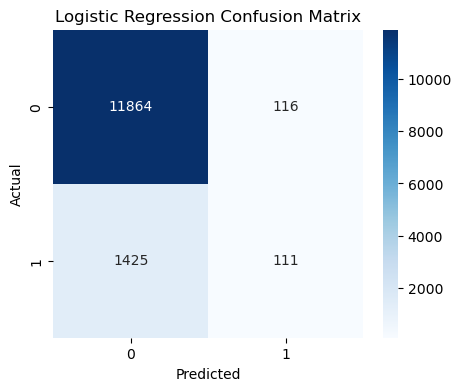

Top 10 features by absolute impact on approval likelihood:
FICO_score                                  1.083872
Ever_Bankrupt_or_Foreclose                 -0.991966
Lender_C                                    0.936635
Lender_B                                   -0.499296
Employment_Status_part_time                -0.316369
Monthly_Gross_Income                        0.164597
Employment_Sector_consumer_staples         -0.150934
Employment_Sector_consumer_discretionary   -0.143973
Reason_credit_card_refinancing              0.082074
Employment_Sector_information_technology    0.066848
dtype: float64


In [173]:
# Evaluate the model
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

# Interpret coefficients
coefficients = pd.Series(lr_model.coef_[0], index=X_encoded.columns)
coefficients_sorted = coefficients.sort_values(key=abs, ascending=False)
print("Top 10 features by absolute impact on approval likelihood:")
print(coefficients_sorted.head(10))

### 3.2 Decision Tree Classifier Model

Build and interpret a Decision Tree Classifier Model to predict the likelihood of loan approval (Approved = 1).



**Question**
How does the Decision Tree’s accuracy and AUC compare to the Logistic Regression model?

**Answer**
The Decision Tree and Logistic Regression perform very similarly overall. The Decision Tree is 89.0% accurate and has a ROC-AUC of 0.770. Logistic Regression has slightly lower accuracy (88.6%) but slightly higher ROC-AUC (0.772). The Decision Tree has slightly higher recall (8% vs 7%) and F1-score (0.14 vs 0.13) for approved loans, meaning it captures a few more actual approvals. Precision is nearly the same (around 0.5). Overall, both models are strong at predicting denials but struggle to identify approvals. Neither model is clearly better, the choice depends on whether you prioritize overall accuracy or better detection of approved applicants.


In [176]:
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Train Decision Tree model

# Prepare features and target
target = 'Approved'
X = df.drop(columns=['Approved', 'bounty'])  # drop only target & irrelevant columns
y = df[target]

# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, drop_first=True)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# Align test set columns to train set
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5, min_samples_split=10)
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Accuracy: 0.8904
ROC-AUC: 0.7701

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.99      0.94     17805
           1       0.50      0.08      0.14      2195

    accuracy                           0.89     20000
   macro avg       0.70      0.53      0.54     20000
weighted avg       0.85      0.89      0.85     20000



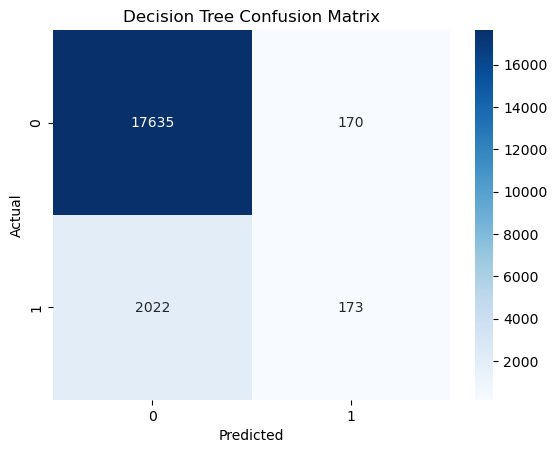

In [178]:
# Evaluate the model
y_pred = dt_model.predict(X_test)
y_prob = dt_model.predict_proba(X_test)[:,1]  # probability for ROC-AUC

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix')
plt.show()

In [180]:
# Variable importance for Decision Tree
# Extract feature importances
importances = pd.Series(dt_model.feature_importances_, index=X_encoded.columns)

# Sort features by importance (descending)
importances_sorted = importances.sort_values(ascending=False)

# Display top 10 important features
top_features = importances_sorted.head(10)
print("Top 10 Important Features for Decision Tree:")
print(top_features)

Top 10 Important Features for Decision Tree:
FICO_score                                  0.631824
Lender_C                                    0.092590
Monthly_Gross_Income                        0.059115
Fico_Score_group_very_good                  0.055292
Fico_Score_group_good                       0.052667
Employment_Status_unemployed                0.041990
Monthly_Housing_Payment                     0.033782
Lender_B                                    0.029816
Requested_Loan_Amount                       0.001885
Employment_Sector_information_technology    0.001039
dtype: float64


### Compare the performance of the Logistic Regression and Decision Tree models.


1.   Compare the performance of the Logistic Regression and Decision Tree
models.

Both models perform similarly overall, with the Decision Tree slightly better at capturing approved loans due to higher recall and F1-score.

2.   Evaluate and compare both models using key metrics such as ROC-AUC, Accuracy, Precision, Recall, and F1-score.

Accuracy is high for both models (Decision Tree 89.0%, Logistic Regression 88.6%), ROC-AUC is slightly higher for Logistic Regression (0.772 vs 0.770), precision for approvals is similar (about 0.5), but recall and F1-score for approvals remain very low, meaning most approved applicants are missed.
   
3. Plot and interpret the confusion matrices for both models. Discuss what false positives and false negatives mean in the business context (for example, approving risky applicants vs. rejecting qualified ones).

Both models are strong at correctly rejecting risky applicants (true negatives) but weak at identifying approved applicants (false negatives), which could result in missed business opportunities. False positives represent risky applicants incorrectly approved, which could increase financial risk.

4. Identify which model best captures the target event (loan approval) and explain why.

The Decision Tree slightly outperforms Logistic Regression in recall and F1-score for approvals, making it the better model for identifying qualified applicants.
   
5. Justify your model choice from both technical (performance, interpretability) and business (actionability, trust, and decision-making) perspectives.

The Decision Tree is preferred because it provides slightly better minority-class performance, is interpretable through feature importance, and offers actionable insights for loan officers, helping reduce missed opportunities while managing risk.

6. Indicate the cutoff threshold you used and why it makes sense for this scenario.

A 0.5 probability threshold was used, balancing risk and opportunity by avoiding too many risky approvals while still identifying some qualified applicants. This threshold could be adjusted depending on business priorities.


In [110]:
model = dt_model  # Decision Tree Classifier is the chosen model

In [112]:
# Save your model as .pkl file for streamlit app development
import pickle

filename = 'my_model.pkl'  # Choose a path and descriptive filename with .pkl extension

# Open the file in binary write mode ('wb')
with open(filename, 'wb') as file:
    pickle.dump(model, file)

print(f"Model saved successfully to {filename}")


Model saved successfully to my_model.pkl


In [114]:
import pickle

# Save the feature names in the exact order your model expects
feature_columns = X_train.columns.tolist()

with open("feature_columns.pkl", "wb") as f:
    pickle.dump(feature_columns, f)

print("Saved", len(feature_columns), "feature columns.")


Saved 29 feature columns.


### My App: https://loanapp-ewtxcfxp3svgdyjhzpw2tb.streamlit.app/

**Question:**
Which model do you recommend and why? (Provide both technical and business reasoning.)

**Answer:** I recommend using the Decision Tree model.

Technically, it does a slightly better job than Logistic Regression at identifying approved loans, so it catches more qualified applicants. It’s also easy to interpret, showing which features most influence approval decisions.

From a business perspective, it’s straightforward to explain to loan officers and stakeholders, helping them understand why applications are approved or denied. This makes decisions more actionable, reduces missed opportunities, and still manages risk effectively.

## 5. Recommendations
In this final section, summarize your key findings and provide concise business recommendations based on your analysis.


**Write a short paragraph including:**  
- A brief summary of your main findings from the analysis and model comparison.  
- The key factors that most influence loan approval.  
- Your recommendations on data or model based on the results  (for example, how approval decisions could be improved or better understood).  
- One next step you would take to improve the model or extend the analysis further.  


**Add your paragraph here:**


My analysis shows that FICO score, lender, income, and prior bankruptcies or foreclosures are the strongest factors influencing loan approval. Both Decision Tree and Logistic Regression models perform similarly overall, but the Decision Tree slightly better identifies approved applicants and is more interpretable. Based on these results, loan approval decisions could be better understood by focusing on these key predictors and using interpretable models like the Decision Tree. A next step would be to address class imbalance or test combining multiple methods (ex. Random Forest) to improve prediction of approved applications.
---



**Question:**  What trade-offs or risks should the company be aware of when using this model?  

**Answer:** The main trade-off is that the model is much better at predicting denials than approvals. This means some qualified applicants may be incorrectly rejected (false negatives), potentially losing revenue and customer satisfaction. Approving risky applicants (false positives) is less common but still a financial risk.

**Question:** How confident are you in your model’s generalizability — what might change its performance in real-world use?   

**Answer:** The model is reasonably confident on similar historical data, but performance could change if applicant demographics, lending policies, or economic conditions shift. Unseen categories in categorical variables or significant changes in income and credit patterns could reduce accuracy and recall.

**Question:** If you had access to additional data, what new feature would you collect to strengthen this model?

**Answer:** Collecting detailed credit history metrics (like number of open accounts, recent delinquencies, credit utilization), employment history length, or debt-to-income ratio could strengthen predictions and improve approval likelihood estimation.